In [1]:
import sys
if sys.platform == 'linux':
    sys.path.append("/home/qix/rCSD")
else:
    sys.path.append("D:/Github/rCSD")

In [2]:
import os, importlib, sys, time, h5py

In [3]:
import numpy as np
from scipy import io, linalg, stats, ndimage
from scipy.sparse import diags

In [4]:
import matplotlib.pyplot as plt
from matplotlib import rc
# rc('font',**{'family':'sans-serif','sans-serif':['Helvetica'], 'size':15})
## for Palatino and other serif fonts use:
# rc('font',**{'family':'serif','serif':['Palatino']})
# rc('text', usetex=True)

In [5]:
import ladyns as ldn
import ladyns.inference as inf
import ladyns.optimize.core as core

In [6]:
importlib.reload(ldn)
importlib.reload(inf)
importlib.reload(core)

<module 'ladyns.optimize.core' from '/home/qix/anaconda3/lib/python3.9/site-packages/ladyns/optimize/core.cpython-39-x86_64-linux-gnu.so'>

# 0. load data

In [7]:
# Load LFP data
from rCSD import CSD, Allen_dataset
import utility_functions as utils
import matplotlib.pyplot as plt

start_time = 0.0
end_time = 0.35
padding = 0.1
V1 = Allen_dataset(fps=1000,
                   start_time=start_time-padding, 
                   end_time=end_time+padding,
#                    orientation=[0],
                   session_id=757216464,
                   probe_id=769322749, 
#                    temporal_frequency=[1,2,4],
#                    stimulus_condition_id=[250,251,258],
                   stimulus_name='drifting_gratings')
V1.get_lfp()
V1.get_running()

# LM = Allen_dataset(fps=500,
#                    start_time=start_time-padding, 
#                    end_time=end_time+padding,
# #                    orientation=[0],
#                    session_id=757216464,
#                    probe_id=769322751, 
# #                    temporal_frequency=[1,2,4],
# #                    stimulus_condition_id=[250,251,258],
#                    stimulus_name='drifting_gratings')
# LM.get_lfp()
# LM.get_running()

# AL = Allen_dataset(fps=500,
#                    start_time=start_time-padding, 
#                    end_time=end_time+padding,
# #                    orientation=[0],
#                    session_id=757216464,
#                    probe_id=769322753, 
# #                    temporal_frequency=[1,2,4],
# #                    stimulus_condition_id=[250,251,258],
#                    stimulus_name='drifting_gratings')
# AL.get_lfp()
# AL.get_running()


/home/qix/anaconda3/lib/python3.9/site-packages/allensdk/brain_observatory/ecephys/stimulus_table/naming_utilities.py:154: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  movie_rows = table[stim_colname].str.contains(movie_re, na=False)


In [8]:
from tqdm import tqdm
from statsmodels.tsa.stattools import grangercausalitytests
from scipy import stats
from astropy.stats import circstats
import copy
from pyTG import torusGraphs

def fill_symmetric(nx, vec):
    inds = np.triu_indices(nx,1)
    mat = np.zeros((nx,nx))
    mat[inds] = vec
    mat = mat+mat.T
    np.fill_diagonal(mat, np.nan)
    return mat

def get_power_phase(data, npadding, lowcut, highcut):
    data = copy.copy(data)
    nx, nt, ntrial = data.shape
    phase = np.zeros((nx, nt-2*npadding, ntrial))
    power = np.zeros((nx, nt-2*npadding, ntrial))

    for itrial in range(ntrial):
        raw_signal = data[:,:,itrial]
        instantaneous_phase, instantaneous_power = utils.get_phase(raw_signal, V1.fps, lowcut=lowcut, highcut=highcut, 
                                                                   npadding=npadding)
        phase[:,:,itrial] = instantaneous_phase
        power[:,:,itrial] = instantaneous_power
    return phase, power


In [9]:
V1.running_trial_index.sum(), V1.stationary_trial_index.sum()

(200, 166)

In [10]:
gap = 1
lfp = V1.lfp[1:-1:gap,:,:]
phase, power = get_power_phase(lfp, npadding=100, lowcut=20.0, highcut=35.0)

In [11]:
power.shape

(91, 350, 630)

In [12]:
merge = 5  # so final fps would be 1000/5=200
new_power = np.zeros((power.shape[0], int(power.shape[1]/merge), power.shape[2]))
for i in range(merge):
    new_power += power[:, i::merge, :]
power = new_power

In [13]:
new_power.shape


(91, 70, 630)

Only look at cortex-thalamus correlation (first one is cortex)

In [14]:
data_stationary = [np.swapaxes(power[61:93,:,V1.stationary_trial_index],0,1), 
                   np.swapaxes(power[0:20,:,V1.stationary_trial_index],0,1)]

In [15]:
data_running = [np.swapaxes(power[61:93,:,V1.running_trial_index],0,1), 
                np.swapaxes(power[0:20,:,V1.running_trial_index],0,1)]

should be [ time, channel, trial ]

In [16]:
data_stationary[0].shape, data_stationary[1].shape

((70, 30, 166), (70, 20, 166))

In [17]:
data_running[0].shape, data_running[1].shape

((70, 30, 200), (70, 20, 200))

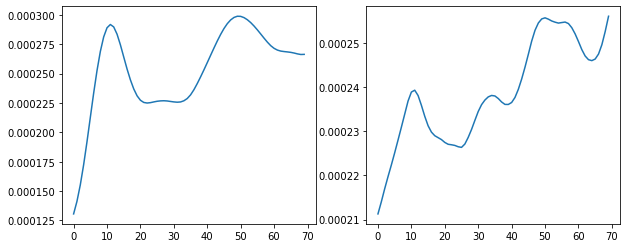

In [18]:
plt.figure(figsize=(10, 4))
plt.subplot(1,2,1); plt.plot(data_running[0][:,:,:].mean(axis=(1,2)))
plt.subplot(1,2,2); plt.plot(data_running[1][:,:,:].mean(axis=(1,2)))
plt.show()

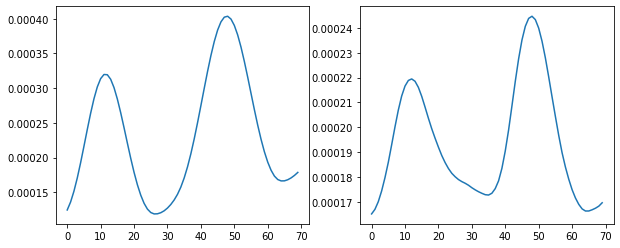

In [19]:
plt.figure(figsize=(10, 4))
plt.subplot(1,2,1); plt.plot(data_stationary[0][:,:,:].mean(axis=(1,2)))
plt.subplot(1,2,2); plt.plot(data_stationary[1][:,:,:].mean(axis=(1,2)))
plt.show()

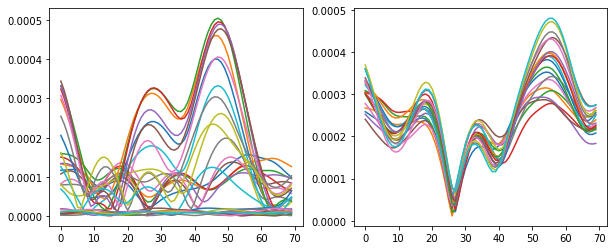

In [20]:
plt.figure(figsize=(10, 4))
plt.subplot(1,2,1); plt.plot(data_stationary[0][:,:,0])
plt.subplot(1,2,2); plt.plot(data_stationary[1][:,:,0])
plt.show()

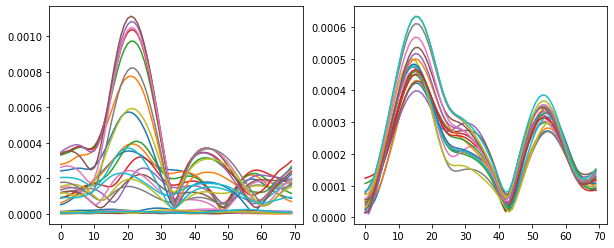

In [21]:
plt.figure(figsize=(10, 4))
plt.subplot(1,2,1); plt.plot(data_running[0][:,:,0])
plt.subplot(1,2,2); plt.plot(data_running[1][:,:,0])
plt.show()

# Stationary

## parameter calibration

In [22]:
data = data_stationary

In [23]:
dims = [data[0].shape[1], data[1].shape[1]]
num_time = data[0].shape[0]
num_trial = data[0].shape[2]
rec_time = [0, 0.35]

In [24]:
offset_cross=20
offset_auto=20
lambdas= np.vstack([
    np.exp(np.linspace(np.log(0.1), np.log(0.001), 11)), #np.full((11,), 0.06), ## lambdas_cross
    np.zeros(11), ## lambdas_auto
    np.full((11,), 0.5), ## lambdas_diag
    np.zeros(11)]) ## lambdas_ridge

In [25]:
time_graph_cross = (np.abs(np.subtract(*np.where(
    np.full([num_time,num_time],True)))
       .reshape([num_time,num_time])) < offset_cross)
time_graph_auto = (np.abs(np.subtract(*np.where(
    np.full([num_time,num_time],True)))
       .reshape([num_time,num_time])) < offset_auto)

In [26]:
b_time = np.linspace(rec_time[0], rec_time[1], num_time)
l_time = np.linspace(rec_time[0], rec_time[1], 2*num_time-1)

### calibration by permutation

In [27]:
num_cv = 10

In [28]:
Omegas_cv = np.zeros([num_cv, lambdas.shape[-1], 2*num_time, 2*num_time])
weights_cv = []

for iter_cv in np.arange(num_cv):
    start_cv = time.time()
    
    # random sample
    trial_sample = np.random.choice(num_trial, num_trial, False)
    data_bst = [data[0], data[1][:,:,trial_sample]]

    for iter_est, (lambda_cross, lambda_auto, lambda_diag, lambda_ridge) \
    in enumerate(zip(*lambdas)): 
        if iter_cv > 0:
            init_arg = {'Omega_init': Omegas_cv[0,iter_est],
                        'weight_init': weights_cv[iter_est]}
        elif iter_est > 0:
            init_arg = {'Omega_init': Omegas_cv[0,iter_est-1],
                        'weight_init': weights_cv[iter_est-1]}
        else:
            init_arg = dict()

        Omega_est, Sigma_est, latent_est, weight_est \
        = ldn.fit(data_bst, lambda_diag, lambda_cross, offset_cross,
                  lambda_auto, offset_auto, 
                  ths_glasso=1e-6, ths_lasso=1e-6, verbose=True,
                  **init_arg)
        
        # save result
        Omegas_cv[iter_cv, iter_est] = Omega_est
        if iter_cv == 0:
            weights_cv.append(weight_est)

    sys.__stdout__.write("%d-th cv finished, lapse: %.3fsec.\n"
                         %(iter_cv+1, time.time()-start_cv))
    sys.__stdout__.flush()

1-th iter, nll: 91.587138, change: 0.460312, lapse: 1.183956
2-th iter, nll: 91.158171, change: 0.077323, lapse: 1.292758
3-th iter, nll: 90.879555, change: 0.046672, lapse: 1.117607
4-th iter, nll: 90.669163, change: 0.044710, lapse: 1.035753
5-th iter, nll: 90.499640, change: 0.040143, lapse: 0.946862
6-th iter, nll: 90.358581, change: 0.034436, lapse: 0.902349
7-th iter, nll: 90.238861, change: 0.028797, lapse: 0.841734
8-th iter, nll: 90.135677, change: 0.023990, lapse: 0.785551
9-th iter, nll: 90.045578, change: 0.022153, lapse: 0.765257
10-th iter, nll: 89.965988, change: 0.021771, lapse: 0.746849
11-th iter, nll: 89.894998, change: 0.021503, lapse: 0.761239
12-th iter, nll: 89.831082, change: 0.021290, lapse: 0.807567
13-th iter, nll: 89.773093, change: 0.020991, lapse: 0.785945
14-th iter, nll: 89.720144, change: 0.020656, lapse: 0.776824
15-th iter, nll: 89.671544, change: 0.020430, lapse: 0.803906
16-th iter, nll: 89.626762, change: 0.020094, lapse: 0.803083
17-th iter, nll: 

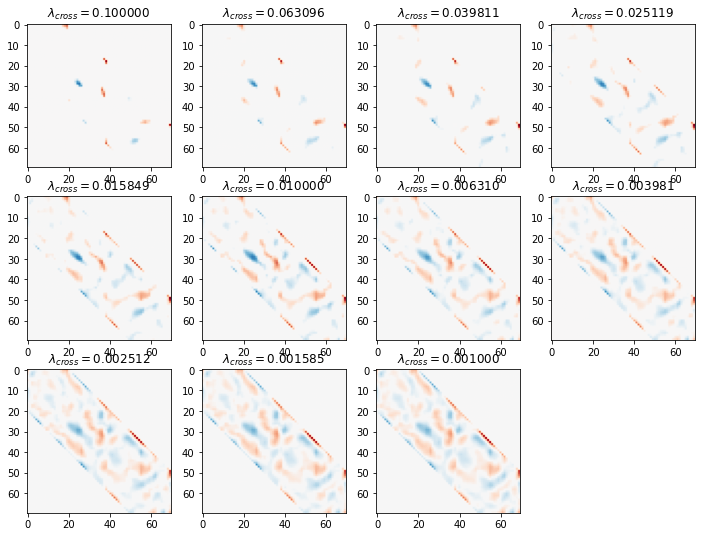

In [29]:
plt.figure(figsize=(12,3*np.ceil(lambdas.shape[-1]/4)))
for iter_lambda, (lambda_cross, lambda_auto, lambda_diag, lambda_ridge) \
in enumerate(zip(*lambdas)):
    plt.subplot(int(np.ceil(lambdas.shape[-1]/4)), 4, iter_lambda+1)
    ldn.imshow(Omegas_cv[0, iter_lambda,:num_time,num_time:], identity=True)
    plt.title(r'$\lambda_{cross} = %f$'%lambda_cross)

In [30]:
fds_cv = np.sum(Omegas_cv[:,:,:num_time,num_time:]!=0,(0,-2,-1))/num_cv
fdrs_cv = np.sum(Omegas_cv[:,:,:num_time,num_time:]!=0,(0,-2,-1))/np.sum(time_graph_cross)/num_cv

Text(0, 0.5, 'mean false discovery')

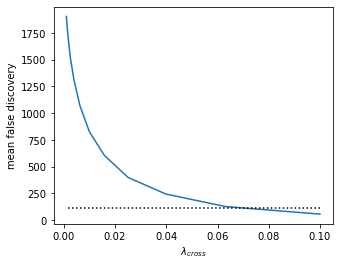

In [31]:
plt.figure(figsize=(5,4))
plt.plot(lambdas[0], fds_cv)
plt.plot(lambdas[0], np.full(lambdas[0].shape, 0.05*np.sum(time_graph_cross)), color='black', linestyle=':')
plt.xlabel(r"$\lambda_{cross}$")
plt.ylabel(r"mean false discovery")

## cv result

In [32]:
id_cv = np.argmax(fdrs_cv[fdrs_cv < 0.05])

In [33]:
lambda_cross, lambda_auto, lambda_diag, lambda_ridge = lambdas.T[id_cv]
lambda_cross, lambda_auto, lambda_diag, lambda_ridge

(0.10000000000000002, 0.0, 0.5, 0.0)

In [34]:
lambda_graph = np.array(np.block(
    [[(1+lambda_auto)*(time_graph_auto-np.eye(num_time)) + (1+lambda_diag)*np.eye(num_time), (1+lambda_cross)*time_graph_cross],
     [(1+lambda_cross)*time_graph_cross, (1+lambda_auto)*(time_graph_auto-np.eye(num_time)) + (1+lambda_diag)*np.eye(num_time)]])) -1

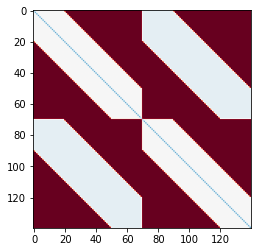

In [35]:
ldn.imshow(lambda_graph)

In [36]:
Omega_est, Sigma_est, latent_est, weight_est =\
    ldn.fit(data, lambda_diag, lambda_cross, offset_cross,
            lambda_auto, offset_auto, 
            ths_glasso=1e-6, ths_lasso=1e-6, verbose=True)

1-th iter, nll: 91.186565, change: 0.460708, lapse: 1.231591
2-th iter, nll: 90.743197, change: 0.077517, lapse: 1.468120
3-th iter, nll: 90.455802, change: 0.047048, lapse: 1.178150
4-th iter, nll: 90.239320, change: 0.044038, lapse: 1.058629
5-th iter, nll: 90.065376, change: 0.039754, lapse: 1.001163
6-th iter, nll: 89.921469, change: 0.034149, lapse: 0.958284
7-th iter, nll: 89.800325, change: 0.028613, lapse: 0.932468
8-th iter, nll: 89.697011, change: 0.023770, lapse: 0.936657
9-th iter, nll: 89.607896, change: 0.021930, lapse: 0.810019
10-th iter, nll: 89.530117, change: 0.021483, lapse: 0.792587
11-th iter, nll: 89.461620, change: 0.021133, lapse: 0.765794
12-th iter, nll: 89.400834, change: 0.020888, lapse: 0.810844
13-th iter, nll: 89.346529, change: 0.020574, lapse: 0.784608
14-th iter, nll: 89.297748, change: 0.020177, lapse: 0.801918
15-th iter, nll: 89.253682, change: 0.019928, lapse: 0.869104
16-th iter, nll: 89.213661, change: 0.019617, lapse: 0.831615
17-th iter, nll: 

In [37]:
dspr_est = 2*Omega_est - Omega_est @ Sigma_est @ Omega_est

### plots

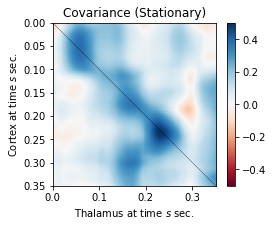

In [103]:
plt.figure(figsize=(4,3))
ldn.imshow(Sigma_est[:num_time,num_time:], time=rec_time, identity=True); plt.colorbar()
plt.xlabel(r"Thalamus at time $s$ sec.")
plt.ylabel(r"Cortex at time $s$ sec.")
plt.title("Covariance (Stationary)")
plt.clim(-0.5,0.5)

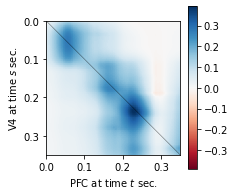

In [83]:
plt.figure(figsize=(3,3))
ldn.imshow(np.linalg.inv(Omega_est)[:num_time,num_time:], time=rec_time, identity=True)
plt.xlabel(r"PFC at time $t$ sec."); plt.ylabel(r"V4 at time $s$ sec.")
plt.colorbar()

Text(0.5, 1.0, 'Cross-precision (Stationary)')

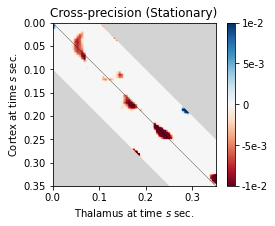

In [102]:
fig, ax = plt.subplots(figsize=(4,3))
ldn.imshow(Omega_est[:num_time,num_time:], time=rec_time, identity=True)

ax.fill_between((b_time[offset_cross], rec_time[1]), 
                (rec_time[0], rec_time[0]), 
                (rec_time[0], rec_time[1]-b_time[offset_cross]+rec_time[0]), color='lightgray')
ax.fill_between((rec_time[0], rec_time[1]-b_time[offset_cross]+rec_time[0]), 
                (b_time[offset_cross], rec_time[1]), 
                (rec_time[1], rec_time[1]), color='lightgray')
# plt.clim(-0.002,0.002); cbar = plt.colorbar(ticks=[-0.002, -0.001, 0.0, 0.001, 0.002])
# cbar.ax.set_yticklabels(['-2e-3','-1e-3','0','1e-3','2e-3'])
plt.clim(-0.01,0.01);
cbar = plt.colorbar(ticks=[-0.01, -0.005, 0.0, 0.005, 0.01])
cbar.ax.set_yticklabels(['-1e-2','-5e-3','0','5e-3','1e-2'])
ax.set_xlim(rec_time[0], rec_time[1])
ax.set_ylim(rec_time[1], rec_time[0])
ax.set_xlabel(r"Thalamus at time $s$ sec.")
ax.set_ylabel(r"Cortex at time $s$ sec.")
plt.title("Cross-precision (Stationary)")

## Permutation test

In [41]:
num_perm = 2000

In [42]:
init_arg = {'Omega_init': Omegas_cv[0,id_cv],
            'weight_init': weights_cv[id_cv]}

In [43]:
Omegas_perm = np.zeros([num_perm, 2*num_time, 2*num_time])
Sigmas_perm = np.zeros([num_perm, 2*num_time, 2*num_time])

for iter_perm in range(num_perm):    
    while True:
        with np.errstate(all='raise'):
            try:
                start_perm = time.time()
                
                # random sample
                trial_sample = np.random.choice(num_trial, num_trial, False)
                data_bst = [data[0], data[1][:,:,trial_sample]]

                # permutation
                Omega_perm, Sigma_perm, latent_perm, weight_perm \
                = ldn.fit(data_bst, lambda_diag, lambda_cross, offset_cross,
                          lambda_auto, offset_auto, 
                          ths_glasso=1e-6, ths_lasso=1e-6, verbose=True,
                          **init_arg)
        
                
            except FloatingPointError:
                sys.__stdout__.write("%d-th permutation encountered FloatingPointError, lapse:%.3fsec.\n"
                                     %(iter_perm+1, time.time()-start_perm))
                sys.__stdout__.write("Retrying...\n")
                sys.__stdout__.flush()
                continue
                
            init_arg = {'Omega_init':Omega_perm, 'weight_init':weight_perm}
                        
            # save result
            Omegas_perm[iter_perm] = Omega_perm
            Sigmas_perm[iter_perm] = Sigma_perm
            
            sys.__stdout__.write("%d-th permutation finished, lapse: %.3fsec.\n"
                          %(iter_perm+1, time.time()-start_perm))
            sys.__stdout__.flush()
            break

1-th iter, nll: 88.056301, change: 0.158002, lapse: 0.670737
2-th iter, nll: 88.053759, change: 0.006507, lapse: 0.642512
3-th iter, nll: 88.051925, change: 0.003114, lapse: 0.619638
4-th iter, nll: 88.050448, change: 0.002133, lapse: 0.611992
5-th iter, nll: 88.049203, change: 0.001621, lapse: 0.576007
6-th iter, nll: 88.048125, change: 0.001312, lapse: 0.569892
7-th iter, nll: 88.047177, change: 0.001108, lapse: 0.595122
8-th iter, nll: 88.046335, change: 0.000962, lapse: 0.603763
1-th permutation finished, lapse: 4.899sec.
1-th iter, nll: 88.045622, change: 0.137040, lapse: 0.694354
2-th iter, nll: 88.044291, change: 0.004675, lapse: 0.610623
3-th iter, nll: 88.043341, change: 0.002437, lapse: 0.587350
4-th iter, nll: 88.042588, change: 0.001646, lapse: 0.600135
5-th iter, nll: 88.041964, change: 0.001265, lapse: 0.588197
6-th iter, nll: 88.041434, change: 0.001037, lapse: 0.602126
7-th iter, nll: 88.040975, change: 0.000876, lapse: 0.559757
2-th permutation finished, lapse: 4.253se

## 3. Inference by STAR

In [107]:
alpha = 0.1
roi = (np.abs(np.subtract(*np.where(
       np.full([num_time,num_time],True)))
       .reshape([num_time,num_time])) < offset_cross-1)

In [108]:
dspr_est = 2*Omega_est - Omega_est @ Sigma_est @ Omega_est
dsprs_perm = 2*Omegas_perm - Omegas_perm @ Sigmas_perm @ Omegas_perm

In [109]:
dist_dspr_est = (dspr_est[:num_time,num_time:] / np.std(dsprs_perm[:,:num_time,num_time:],0))

In [110]:
pval_est = np.full(dist_dspr_est.shape, 0.5)
pval_est[roi] = np.clip(2*stats.norm.cdf(-np.abs(dist_dspr_est[roi])), 1e-10, 1-1e-10)

In [111]:
R, fdp, score, mask = \
    inf.STAR_seq_step(pval_est, prop_carve = 0.05, alphas = [alpha],
                      sigma=1, mux_init=-np.log(alpha), roi=roi)
rej_STAR = mask[0]

### plots

Text(0.5, 1.0, 'Stationary')

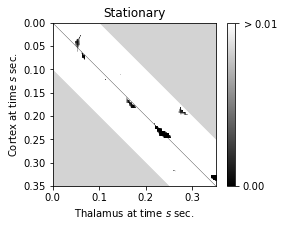

In [112]:
plt.figure(figsize=(4,3))
ldn.imshow(pval_est, cmap='gray', vmin=0, vmax=0.01, time=rec_time, identity=True)
plt.fill_between((b_time[offset_cross], rec_time[1]), 
                (rec_time[0], rec_time[0]), 
                (rec_time[0], rec_time[1]-b_time[offset_cross]+rec_time[0]), color='lightgray')
plt.fill_between((rec_time[0], rec_time[1]-b_time[offset_cross]+rec_time[0]), 
                (b_time[offset_cross], rec_time[1]), 
                (rec_time[1], rec_time[1]), color='lightgray')

cbar = plt.colorbar(ticks=[0, 0.01])
cbar.ax.set_yticklabels(['0.00','$>$0.01'])
plt.xlabel(r"Thalamus at time $s$ sec.")
plt.ylabel(r"Cortex at time $s$ sec.")
plt.title("Stationary")
# plt.yticks([0.0, 0.1, 0.2, 0.3, 0.4, 0.5], ['','','','','','',''])

Text(0.5, 1.0, 'Stationary')

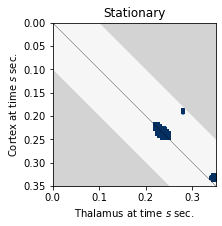

In [113]:
fig, ax = plt.subplots(figsize=(3,3))
ldn.imshow(rej_STAR, time=rec_time, identity=True)

ax.fill_between((b_time[offset_cross], rec_time[1]), 
                (rec_time[0], rec_time[0]), 
                (rec_time[0], rec_time[1]-b_time[offset_cross]+rec_time[0]), color='lightgray')
ax.fill_between((rec_time[0], rec_time[1]-b_time[offset_cross]+rec_time[0]), 
                (b_time[offset_cross], rec_time[1]), 
                (rec_time[1], rec_time[1]), color='lightgray')
plt.clim(-0.001,0.001); # cbar = plt.colorbar(ticks=[-0.010, -0.005, 0.0, 0.005, 0.01])
# cbar.ax.set_yticklabels([r'$<$ -0.010','-0.005','0.000','0.005',r'$>$ 0.010'])
ax.set_xlim(rec_time[0], rec_time[1]), ax.set_ylim(rec_time[1], rec_time[0])
plt.xlabel(r"Thalamus at time $s$ sec.")
plt.ylabel(r"Cortex at time $s$ sec.")
plt.title("Stationary")
# plt.yticks([0.0, 0.1, 0.2, 0.3, 0.4, 0.5], ['','','','','','',''])

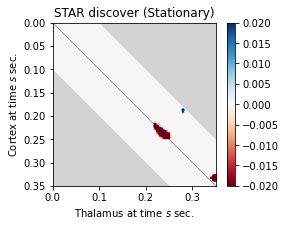

In [114]:
plt.figure(figsize=(4,3))
ldn.imshow(rej_STAR * dspr_est[:num_time,num_time:], time=rec_time, identity=True)
plt.fill_between((b_time[offset_cross], rec_time[1]), 
                (rec_time[0], rec_time[0]), 
                (rec_time[0], rec_time[1]-b_time[offset_cross]+rec_time[0]), color='lightgray')
plt.fill_between((rec_time[0], rec_time[1]-b_time[offset_cross]+rec_time[0]), 
                (b_time[offset_cross], rec_time[1]), 
                (rec_time[1], rec_time[1]), color='lightgray')
# cbar.ax.set_yticklabels([r'$<$ -2e-3','-1e-3','0','1e-3',r'$>$ 2e-3'])
plt.xlim(rec_time[0], rec_time[1]); plt.ylim(rec_time[1], rec_time[0])
plt.xlabel(r"Thalamus at time $s$ sec.")
plt.ylabel(r"Cortex at time $s$ sec.")
plt.title("STAR discover (Stationary)")
plt.colorbar()
plt.clim(-0.02,0.02)
# cbar = plt.colorbar(ticks=[-0.006, -0.003, 0.0, 0.003, 0.006])
# cbar.ax.set_yticklabels([r'-6e-3','-3e-3','0','3e-3',r'6e-3'])